# Université du Québec à Chicoutimi (UQAC)
## 8INF926 — Atelier en optimisation avancée
### Projet 2 (Hiver 2026) — Optimisation boîte noire avec NOMAD

> Professeure : Sara Séguin  
Date : avril 2026

> Objectif : résoudre le problème de répartition des débits par turbine avec **NOMAD** et comparer les résultats avec la partie DP du Projet 1.

**Livrables produits par ce notebook** :
- `partie2_validation_100_resultats_nomad.csv` (détail par ligne)
- `partie2_validation_100_summary_nomad.csv` (métriques globales)
- `partie2_nomad_iterations_100.png`
- `partie2_nomad_temps_100.png`

## Table des matières (guide de lecture)

1. Formulation du problème (boîte noire)
2. Modèle analytique réutilisé (Projet 1)
3. Exécution NOMAD sur les 100 premières lignes
4. Export des résultats
5. Comparaison NOMAD vs DP
6. Graphiques demandés

## II.1 Problème d’optimisation (NOMAD)

Pour une consigne de débit total $Q_{tot}$ et une élévation amont $N_{amont}$, on cherche la répartition
$\mathbf{Q}=(Q_1,\dots,Q_5)$ qui maximise la puissance totale.

### Fonction objectif
$$
\max_{Q_1,\dots,Q_5} \; \sum_{i=1}^5 P_i(Q_i, H_{n,i})
$$
avec
$$
H_{n,i} = N_{amont} - Elav(Q_{tot}) - 0.5\times 10^{-5}\,Q_i^2
$$

### Contraintes
$$
\sum_{i=1}^5 Q_i = Q_{tot}, \qquad 0 \le Q_i \le \overline{Q}_i
$$
où $\overline{Q}_i=160$ m³/s par défaut, ou $0$ si turbine indisponible.

### Variables discrètes
Comme dans le Projet 1 (DP), on garde $\Delta Q=5$ m³/s et on optimise
$x_i\in\mathbb{Z}$ avec $Q_i = 5x_i$.

### Format boîte noire NOMAD
NOMAD minimise. On utilise donc:
- Objectif : $f(x)=-P_{tot}(x)$
- Contraintes PB : $g_1(x)=\sum Q_i-Q_{tot}\le 0$, $g_2(x)=Q_{tot}-\sum Q_i\le 0$

## Exécution

1. Vérifier que `nomad` est installé et disponible dans `PATH`.
2. Exécuter les cellules dans l’ordre.
3. Ajuster au besoin : nombre de cas (`N_TEST`), budget d’évaluations (`MAX_EVAL`) et timeout (`TIMEOUT_S`).

### Installation des dépendances
Cette étape prépare l’environnement Python avec `pandas`, `openpyxl` et `matplotlib`.

In [8]:
# Installation (une seule fois)
# Cette cellule installe seulement les dépendances Python du notebook.
# L'exécutable NOMAD doit déjà être installé séparément sur la machine.
import sys
!{sys.executable} -m pip install -q pandas openpyxl matplotlib
print('Dépendances installées (pandas/openpyxl/matplotlib).')

/bin/bash: line 1: /home/johanu/Downloads/cours_uqac/8INF926: No such file or directory
Dépendances installées (pandas/openpyxl/matplotlib).


### Imports Python
Les modules standards, `pandas` et `matplotlib` sont chargés pour la préparation des données, l’exécution NOMAD et la visualisation.

In [9]:
from __future__ import annotations
# dataclass/field servent à définir proprement le modèle hydraulique et ses coefficients.
from dataclasses import dataclass, field
from pathlib import Path
from statistics import mean
from typing import List, Tuple, Sequence, Dict
import csv, json, math, os, shutil, subprocess, time
import pandas as pd
import matplotlib.pyplot as plt

print('Imports chargés OK.')

Imports chargés OK.


### Paramètres d’exécution et détection de NOMAD
On définit les chemins de travail, les paramètres de test (`N_TEST`, `MAX_EVAL`, `TIMEOUT_S`) et la détection de l’exécutable `nomad`.

In [ ]:
# Paramètres d'exécution
# Tous les fichiers de sortie sont écrits relativement au dossier du notebook.
ROOT = Path.cwd()
XLSX_PATH = ROOT / 'DataProjet2026.xlsx'
OUT_DETAIL = ROOT / 'partie2_validation_100_resultats_nomad.csv'
OUT_SUMMARY = ROOT / 'partie2_validation_100_summary_nomad.csv'
PLOT_ITER = ROOT / 'images-projet2/partie2_nomad_iterations_100.png'
PLOT_TIME = ROOT / 'images-projet2/partie2_nomad_temps_100.png'
DP_DETAIL = ROOT / 'partie2_validation_100_resultats_python.csv'
DP_SUMMARY = ROOT / 'partie2_validation_100_summary_python.csv'

N_TEST = 100
# DQ est le pas de discrétisation: NOMAD travaille sur des entiers x_i,
# puis la boîte noire reconstruit Q_i = DQ * x_i.
DQ = 5
MAX_EVAL = 500
TIMEOUT_S = 180

# Détection robuste de NOMAD (kernel Jupyter != terminal shell)
nomad_candidates = [
    os.environ.get('NOMAD_EXE', ''),
    shutil.which('nomad') or '',
    '/home/johanu/nomad-4.5.1/build/release/bin/nomad',
]

NOMAD_EXE = None
# On prend le premier exécutable valide trouvé dans la liste de candidats.
for cand in nomad_candidates:
    if cand and Path(cand).exists() and os.access(cand, os.X_OK):
        NOMAD_EXE = str(Path(cand).resolve())
        break

if NOMAD_EXE is None:
    raise RuntimeError(
        'NOMAD introuvable pour le noyau Jupyter. '\
        'Dans une nouvelle cellule, exécute: '\
        "import os; os.environ['PATH']='/home/johanu/nomad-4.5.1/build/release/bin:' + os.environ['PATH'] "
        'puis relance cette cellule.'
    )

print('NOMAD détecté :', NOMAD_EXE)
print('PATH kernel    :', os.environ.get('PATH', ''))
print('Dossier projet :', ROOT)
print('Fichier Excel  :', XLSX_PATH)

NOMAD détecté : /home/johanu/nomad-4.5.1/build/release/bin/nomad-4.5.1
PATH kernel    : /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/.venv/bin:/home/johanu/.local/bin:/home/johanu/.local/share/mise/installs/node/22.18.0/bin:/home/johanu/.local/share/mise/installs/ruby/3.4.6/bin:/home/johanu/miniconda3/bin:/home/johanu/miniconda3/condabin:/home/johanu/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin:/usr/local/MATLAB/R2024b/bin
Dossier projet : /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2
Fichier Excel  : /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/DataProjet2026.xlsx.xlsx


### Fonctions utilitaires et modèle hydraulique
Cette partie met en place les fonctions de lecture/normalisation ainsi que la classe `HydroPlantModel`, reprise du Projet 1 pour calculer les puissances.

In [11]:
# Outils lecture + modèle analytique (identique Projet 1)
def normalize_name(name: str) -> str:
    # Uniformise les en-têtes Excel pour rendre la recherche de colonnes robuste.
    return ' '.join(str(name).replace('\n', ' ').replace('\r', ' ').split()).lower()

def pick_column(columns: List[str], aliases: List[str]) -> str:
    norm_map = {normalize_name(c): c for c in columns}
    for a in aliases:
        key = normalize_name(a)
        if key in norm_map:
            return norm_map[key]
    raise KeyError(f'Colonne introuvable. Aliases testés: {aliases}')

def to_float(v) -> float:
    # Convertit les valeurs Excel en flottants et retourne NaN si la conversion échoue.
    if v is None or v == '' or (hasattr(pd, 'isna') and pd.isna(v)):
        return float('nan')
    try:
        return float(v)
    except Exception:
        return float('nan')

def read_excel_table(file_path: Path, header_row_1based: int = 3) -> pd.DataFrame:
    # Le fichier source contient les vrais noms de colonnes à partir de la ligne 3.
    header = header_row_1based - 1
    df = pd.read_excel(file_path, header=header, engine='openpyxl')
    df = df.dropna(how='all')
    df.columns = [str(c).replace('\n', ' ').replace('\r', ' ').strip() for c in df.columns]
    df = df[[c for c in df.columns if not str(c).strip().lower().startswith('unnamed:')]]
    return df

@dataclass
class HydroPlantModel:
    elav_coeff: Tuple[float, float, float] = (-1.453e-6, 7.022e-3, 99.98)
    turb_coeff: List[Tuple[float, ...]] = field(default_factory=lambda: [
        (876.5404, -12.3376, -23.7066, 0.0181, 0.5931, -0.5985, -0.0006, -0.0059, 0.0147),
        (568.5323, -6.5275, -25.9285, 0.0123, 0.3086, 0.1932, -0.0004, -0.0025, 0.0009),
        (-2502.4, 9.9767, 178.7178, -0.0138, -0.4584, -4.2689, 3.6178e-4, 0.0054, 0.0340),
        (3347.6, -18.2111, -224.2315, 0.0234, 0.9174, 4.7799, -7.8865e-4, -0.0101, -0.0334),
        (-1452.7, 6.8356, 94.1139, -0.0131, -0.2594, -2.0887, 3.3149e-4, 0.0024, 0.0162),
    ])

    @staticmethod
    def _loss(qi: float) -> float:
        # Pertes de charge quadratiques dans la conduite forcée.
        return 0.5e-5 * qi * qi

    def elav(self, qtot: float) -> float:
        # Modèle polynomial de l'élévation avale appris au Projet 1.
        a2, a1, a0 = self.elav_coeff
        return a2 * qtot * qtot + a1 * qtot + a0

    def hnet(self, niv_amont: float, qtot: float, qi: float) -> float:
        # Hauteur nette = niveau amont - élévation avale - pertes hydrauliques.
        return niv_amont - self.elav(qtot) - self._loss(qi)

    def power_unit(self, turbine_idx_1based: int, qi: float, niv_amont: float, qtot: float) -> float:
        if qi <= 0:
            return 0.0
        # Chaque turbine possède sa propre surface poly23 calibrée au Projet 1.
        c = self.turb_coeff[turbine_idx_1based - 1]
        h = self.hnet(niv_amont, qtot, qi)
        p = (
            c[0] + c[1]*qi + c[2]*h + c[3]*qi*qi + c[4]*qi*h + c[5]*h*h +
            c[6]*qi*qi*h + c[7]*qi*h*h + c[8]*h*h*h
        )
        return max(0.0, p)

    def power_dispatch(self, q_vec: Sequence[float], niv_amont: float, qtot: float) -> Tuple[List[float], float]:
        # Retourne la puissance par turbine ainsi que la puissance totale du dispatch.
        p_vec = [self.power_unit(i + 1, q_vec[i], niv_amont, qtot) for i in range(len(q_vec))]
        return p_vec, float(sum(p_vec))

print('Utilitaires et modèle prêts.')

Utilitaires et modèle prêts.


### Exécution NOMAD sur les cas de validation
NOMAD est lancé sur les lignes de test, la meilleure solution faisable est récupérée, puis les sorties détaillées et le résumé global sont exportés.

In [ ]:
# Exécution NOMAD sur 100 cas
model = HydroPlantModel()
df = read_excel_table(XLSX_PATH, header_row_1based=3)
rows = df.to_dict(orient='records')
cols = list(df.columns)

# Identification robuste des colonnes utiles dans le fichier Excel.
c_qtot = pick_column(cols, ['Qtot (m3/s)'])
c_niv = pick_column(cols, ['Niv Amont (m)'])
c_q = [
    pick_column(cols, ['Q1 (m3/s)']),
    pick_column(cols, ['Q2 (m3/s)']),
    pick_column(cols, ['Q3 (m3/s)']),
    pick_column(cols, ['Q4 (m3/s)']),
    pick_column(cols, ['Q5 (m3/s)']),
]
c_p = [
    pick_column(cols, ['P1 (MW)']),
    pick_column(cols, ['P2 (MW)']),
    pick_column(cols, ['P3 (MW)']),
    pick_column(cols, ['P4 (MW)']),
    pick_column(cols, ['P5 (MW)']),
]

# Les exécutions NOMAD sont faites dans /tmp pour éviter d'encombrer le dépôt.
run_dir = Path('/tmp/nomad_p2_runs_notebook')
run_dir.mkdir(parents=True, exist_ok=True)
link_root = Path('/tmp/projet2_nomad_link_notebook')
if not link_root.exists():
    if link_root.is_symlink() or link_root.exists():
        link_root.unlink()
    os.symlink(str(ROOT), str(link_root), target_is_directory=True)

blackbox_py = link_root / 'nomad_p2' / 'nomad_blackbox.py'
if not blackbox_py.exists():
    raise FileNotFoundError(f'Boîte noire introuvable: {blackbox_py}. Assure-toi davoir le dossier nomad_p2.')

def make_feasible_x0(qtot_d: int, dq: int, ub_x: List[int]) -> List[int]:
    # Construit un point initial faisable en répartissant progressivement le débit.
    # Cela aide NOMAD à démarrer depuis une solution respectant déjà la contrainte de somme.
    target = qtot_d // dq
    x = [0]*5
    i = 0
    while target > 0 and i < 10000:
        t = i % 5
        if x[t] < ub_x[t]:
            x[t] += 1
            target -= 1
        i += 1
    return x

def write_param(path: Path, x0: List[int], ub_x_nomad: List[int], bb_exe: str) -> None:
    # Fichier de paramètres lu par NOMAD pour un cas donné.
    # OBJ = objectif, PB = contrainte progressive de boîte noire.
    txt = '\n'.join([
        'DIMENSION 5',
        'BB_OUTPUT_TYPE OBJ PB PB',
        'BB_INPUT_TYPE (I I I I I)',
        f'BB_EXE {bb_exe}',
        'LOWER_BOUND (0 0 0 0 0)',
        f"UPPER_BOUND ({' '.join(str(v) for v in ub_x_nomad)})",
        f"X0 ({' '.join(str(v) for v in x0)})",
        'DISPLAY_DEGREE 0',
        f'MAX_EVAL {MAX_EVAL}',
        f'MAX_BB_EVAL {MAX_EVAL}',
        ''
    ])
    path.write_text(txt, encoding='utf-8')

out_rows = []
err_mw, err_pct, solve_times, eval_counts = [], [], [], []
n_test = min(N_TEST, len(rows))

for i in range(n_test):
    # Lecture des données réelles de la ligne i du fichier Excel.
    r = rows[i]
    qtot = to_float(r[c_qtot])
    niv = to_float(r[c_niv])
    q_real = [to_float(r[x]) for x in c_q]
    p_real_vec = [to_float(r[x]) for x in c_p]

    if any(math.isnan(x) for x in [qtot, niv] + q_real + p_real_vec):
        continue

    # On projette Qtot sur la grille de 5 m^3/s pour rester cohérent avec les variables entières.
    qtot_d = int(round(qtot / DQ) * DQ)
    qmax = [160.0]*5
    for t in range(5):
        # Si une turbine est à débit nul dans les données, on la considère indisponible ici.
        if q_real[t] == 0:
            qmax[t] = 0.0

    ub_x_real = [int(math.floor(v / DQ)) for v in qmax]
    # NOMAD ne gère pas bien une borne supérieure nulle dans cette formulation,
    # donc on met 1 côté NOMAD puis la boîte noire re-sature physiquement à qmax.
    ub_x_nomad = [u if u > 0 else 1 for u in ub_x_real]
    x0 = make_feasible_x0(qtot_d, DQ, ub_x_real)

    case_dir = run_dir / f'case_{i+1:03d}'
    case_dir.mkdir(parents=True, exist_ok=True)

    eval_log_csv = case_dir / 'eval_log.csv'
    case_json = case_dir / 'case.json'
    param_txt = case_dir / 'nomad.param'
    bb_wrapper = case_dir / 'bb_wrapper.sh'

    # case.json transporte toutes les données hydrauliques nécessaires à la boîte noire.
    case_obj = {
        'row': i + 1,
        'qtot_input': qtot,
        'qtot_discretized': qtot_d,
        'niv_amont': niv,
        'qmax_by_turbine': qmax,
        'dq': DQ,
        'eval_log_csv': str(eval_log_csv),
    }
    case_json.write_text(json.dumps(case_obj, ensure_ascii=False, indent=2), encoding='utf-8')

    # Le wrapper permet à NOMAD d'appeler toujours la même commande locale,
    # même si le notebook est exécuté depuis un autre répertoire de travail.
    bb_wrapper.write_text(
        '#!/usr/bin/env bash\n'
        'set -e\n'
        f'python3 "{blackbox_py}" "{case_json}" "$@"\n',
        encoding='utf-8'
    )
    bb_wrapper.chmod(0o755)

    # Génère le fichier nomad.param propre à ce cas, puis lance le solveur.
    write_param(param_txt, x0, ub_x_nomad, './bb_wrapper.sh')

    t0 = time.perf_counter()
    proc = subprocess.run(
        [NOMAD_EXE, str(param_txt)],
        cwd=str(case_dir),
        capture_output=True,
        text=True,
        timeout=TIMEOUT_S,
    )
    dt = time.perf_counter() - t0

    if proc.returncode != 0:
        raise RuntimeError(f'Erreur NOMAD au cas {i+1}\nstdout:\n{proc.stdout}\n\nstderr:\n{proc.stderr}')

    if not eval_log_csv.exists():
        raise RuntimeError(f'Aucune évaluation enregistrée au cas {i+1}: {eval_log_csv}')

    eval_df = pd.read_csv(eval_log_csv)
    # On privilégie la meilleure solution faisable; sinon on garde la meilleure évaluée.
    feas = eval_df[(eval_df['g1'] <= 1e-9) & (eval_df['g2'] <= 1e-9)]
    best = feas.loc[feas['f'].idxmin()] if len(feas) > 0 else eval_df.loc[eval_df['f'].idxmin()]

    q_opt = [float(best[f'q{k}']) for k in range(1,6)]
    p_opt_vec = [float(best[f'P{k}']) for k in range(1,6)]
    p_opt = float(best['Ptot'])

    # Comparaison entre la puissance observée dans les données et la puissance optimisée par NOMAD.
    p_real = float(sum(p_real_vec))
    e = p_opt - p_real
    ep = (100.0 * e / p_real) if p_real != 0 else float('nan')

    err_mw.append(e)
    if not math.isnan(ep):
        err_pct.append(abs(ep))
    solve_times.append(dt)
    eval_counts.append(int(len(eval_df)))

    out_rows.append({
        'Row': i + 1,
        'Qtot_input': qtot,
        'Qtot_discretized': qtot_d,
        'NivAmont': niv,
        'P_real_total': p_real,
        'P_opt_total_nomad': p_opt,
        'Err_MW_nomad_minus_real': e,
        'Err_pct_nomad_minus_real': ep,
        'N_eval_nomad': int(len(eval_df)),
        'SolveTime_s_nomad': dt,
        'SolverMode': 'nomad',
        'Q1_opt_nomad': q_opt[0],
        'Q2_opt_nomad': q_opt[1],
        'Q3_opt_nomad': q_opt[2],
        'Q4_opt_nomad': q_opt[3],
        'Q5_opt_nomad': q_opt[4],
        'P1_opt_nomad': p_opt_vec[0],
        'P2_opt_nomad': p_opt_vec[1],
        'P3_opt_nomad': p_opt_vec[2],
        'P4_opt_nomad': p_opt_vec[3],
        'P5_opt_nomad': p_opt_vec[4],
    })

    if (i + 1) % 10 == 0:
        print(f'Cas traités: {i+1}/{n_test}')

if len(out_rows) == 0:
    raise RuntimeError('Aucun cas valide traité.')

# Métriques globales agrégées sur tous les cas traités.
mae = mean(abs(x) for x in err_mw)
rmse = math.sqrt(mean(x*x for x in err_mw))
mape = mean(err_pct) if err_pct else float('nan')
mean_eval = mean(eval_counts)
max_eval_observed = max(eval_counts)
t_mean_ms = 1000.0 * mean(solve_times)
t_max_ms = 1000.0 * max(solve_times)

with OUT_DETAIL.open('w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=list(out_rows[0].keys()))
    w.writeheader()
    w.writerows(out_rows)

summary = {
    'MAE_MW_nomad': mae,
    'RMSE_MW_nomad': rmse,
    'MAPE_pct_nomad': mape,
    'MeanEval_nomad': mean_eval,
    'MaxEval_nomad': max_eval_observed,
    'MeanSolveTime_ms_nomad': t_mean_ms,
    'MaxSolveTime_ms_nomad': t_max_ms,
    'SolverMode': 'nomad',
    'Ncases': len(out_rows),
}

if DP_DETAIL.exists():
    # Si les résultats DP sont présents, on ajoute une comparaison directe NOMAD vs DP.
    dp = pd.read_csv(DP_DETAIL)
    nm = pd.DataFrame(out_rows)
    m = nm.merge(dp[['Row','P_opt_total']], on='Row', how='inner')
    if len(m) > 0:
        diff = (m['P_opt_total_nomad'] - m['P_opt_total']).tolist()
        summary['MeanDiffNomadMinusDP_MW'] = float(mean(diff))
        summary['MAE_NomadVsDP_MW'] = float(mean(abs(x) for x in diff))

with OUT_SUMMARY.open('w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=list(summary.keys()))
    w.writeheader()
    w.writerow(summary)

print('Fichiers générés:')
print(' -', OUT_DETAIL)
print(' -', OUT_SUMMARY)

Cas traités: 10/100
Cas traités: 20/100
Cas traités: 30/100
Cas traités: 40/100
Cas traités: 50/100
Cas traités: 60/100
Cas traités: 70/100
Cas traités: 80/100
Cas traités: 90/100
Cas traités: 100/100
Fichiers générés:
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_validation_100_resultats_nomad.csv
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_validation_100_summary_nomad.csv


### Graphiques globaux requis
Les deux graphiques demandés sont générés et sauvegardés : nombre d’évaluations et temps de résolution sur l’ensemble des tests.

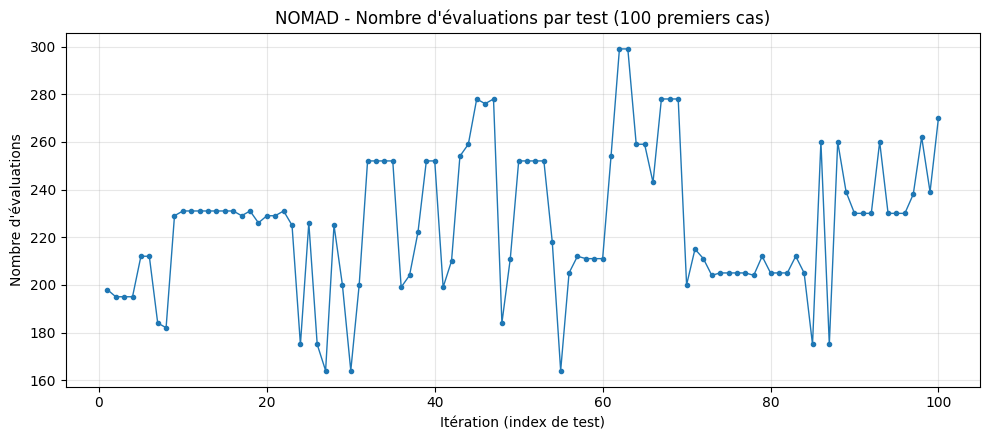

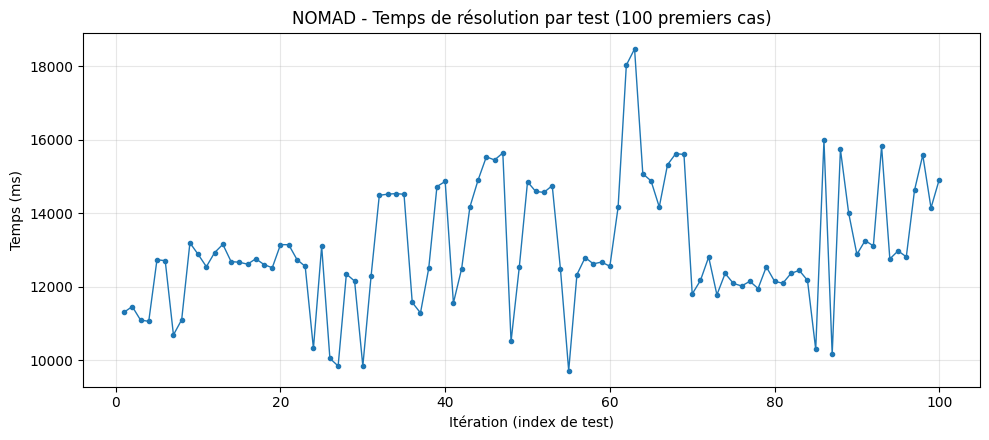

Graphiques sauvegardés :
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_nomad_iterations_100.png
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_nomad_temps_100.png


In [13]:
# Graphiques demandés : nombre d'évaluations et temps sur 100 cas
df_nomad = pd.read_csv(OUT_DETAIL)

# Figure 1: nombre d'évaluations de boîte noire par cas.
plt.figure(figsize=(10,4.5))
plt.plot(df_nomad['Row'], df_nomad['N_eval_nomad'], marker='o', ms=3, lw=1)
plt.title("NOMAD - Nombre d'évaluations par test (100 premiers cas)")
plt.xlabel('Itération (index de test)')
plt.ylabel("Nombre d'évaluations")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_ITER, dpi=160)
plt.show()

# Figure 2: temps total de résolution NOMAD par cas (conversion en ms pour le rapport).
plt.figure(figsize=(10,4.5))
plt.plot(df_nomad['Row'], 1000.0 * df_nomad['SolveTime_s_nomad'], marker='o', ms=3, lw=1)
plt.title("NOMAD - Temps de résolution par test (100 premiers cas)")
plt.xlabel('Itération (index de test)')
plt.ylabel('Temps (ms)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_TIME, dpi=160)
plt.show()

print('Graphiques sauvegardés :')
print(' -', PLOT_ITER)
print(' -', PLOT_TIME)

### Résumé
Les métriques NOMAD et les puissances optimisées.

In [16]:
# Résumé
print('=== Résumé NOMAD ===')
df_summary_nomad = pd.read_csv(OUT_SUMMARY)
display(df_summary_nomad)

print('=== Aperçu des résultats détaillés NOMAD ===')
df_detail_nomad = pd.read_csv(OUT_DETAIL)
display(df_detail_nomad.head(10))

=== Résumé NOMAD ===


,MAE_MW_nomad,RMSE_MW_nomad,MAPE_pct_nomad,MeanEval_nomad,MaxEval_nomad,MeanSolveTime_ms_nomad,MaxSolveTime_ms_nomad,SolverMode,Ncases,MeanDiffNomadMinusDP_MW,MAE_NomadVsDP_MW
0,43.024279,45.099675,23.788065,225.77,299,13073.150158,18469.800724,nomad,100,-0.008688,0.008688


=== Aperçu des résultats détaillés NOMAD ===


,Row,Qtot_input,Qtot_discretized,NivAmont,P_real_total,P_opt_total_nomad,Err_MW_nomad_minus_real,Err_pct_nomad_minus_real,N_eval_nomad,SolveTime_s_nomad,...,Q1_opt_nomad,Q2_opt_nomad,Q3_opt_nomad,Q4_opt_nomad,Q5_opt_nomad,P1_opt_nomad,P2_opt_nomad,P3_opt_nomad,P4_opt_nomad,P5_opt_nomad
0,1,578.005676,580,137.899994,179.173747,235.361086,56.187339,31.359136,198,11.307664,...,150.0,160.0,-0.0,145.0,125.0,56.195512,84.846574,0.0,54.385214,39.933786
1,2,580.299561,580,137.889999,179.500359,235.288914,55.788556,31.079913,195,11.462225,...,150.0,160.0,0.0,145.0,125.0,56.176831,84.824389,0.0,54.367427,39.920267
2,3,578.553650,580,137.889999,179.125606,235.288914,56.163308,31.354148,195,11.096344,...,150.0,160.0,0.0,145.0,125.0,56.176831,84.824389,0.0,54.367427,39.920267
3,4,580.230225,580,137.889999,179.507322,235.288914,55.781593,31.074829,195,11.059279,...,150.0,160.0,0.0,145.0,125.0,56.176831,84.824389,0.0,54.367427,39.920267
4,5,574.046082,575,137.889999,178.303905,233.834363,55.530458,31.143714,212,12.735942,...,145.0,160.0,0.0,145.0,125.0,54.579437,84.883647,0.0,54.414928,39.956352
5,6,576.181702,575,137.889999,178.724086,233.834363,55.110277,30.835395,212,12.708740,...,145.0,160.0,0.0,145.0,125.0,54.579437,84.883647,0.0,54.414928,39.956352
6,7,579.881836,580,137.880005,179.267774,235.216678,55.948903,31.209683,184,10.690741,...,150.0,160.0,0.0,145.0,125.0,56.158156,84.802182,0.0,54.349617,39.906724
7,8,573.768188,575,137.880005,178.042425,233.762899,55.720474,31.296178,182,11.103475,...,145.0,160.0,0.0,145.0,125.0,54.561346,84.861500,0.0,54.397179,39.942875
8,9,567.085449,565,137.880005,176.704973,230.814977,54.110004,30.621665,229,13.195830,...,145.0,160.0,0.0,140.0,120.0,54.658603,84.980127,0.0,52.841139,38.335108
9,10,567.583374,570,137.880005,176.706689,232.303340,55.596650,31.462674,231,12.880495,...,145.0,160.0,0.0,140.0,125.0,54.609867,84.920816,0.0,52.793710,39.978947


## Notes pour le rapport

- Utiliser `partie2_validation_100_summary_nomad.csv` pour les métriques globales NOMAD.
- Utiliser `partie2_validation_100_resultats_nomad.csv` pour les tableaux détaillés.
- Comparer avec les fichiers DP du Projet 1 pour la section discussion.
- Inclure les deux graphes demandés (itérations et temps) ainsi que les graphes du notebook de comparaison.